In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import nltk
nltk.download('stopwords')
nltk.download('punkt')
from nltk.corpus import stopwords
import re
import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Arbab\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Arbab\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.


In [2]:
data = {
    'ticket_text': [
        'My account has been hacked and I cannot login',
        'The app crashes every time I open it',
        'I was charged twice for my subscription',
        'How do I reset my password?',
        'The website is down and I cannot access my data',
        'I need to update my billing information',
        'Product not delivered after 2 weeks',
        'I want to cancel my subscription',
        'Error 500 when trying to checkout',
        'My payment was declined but money was deducted',
        'Cannot connect to the server',
        'How do I change my email address?',
        'Refund not received after 10 days',
        'App is very slow and freezing',
        'I got logged out and cannot get back in',
        'Wrong item was delivered to me',
        'The login button is not working',
        'I need a receipt for my last purchase',
        'Database connection timeout error',
        'My subscription was cancelled without notice',
        'System is down since morning',
        'How to export my data?',
        'Unauthorized charge on my credit card',
        'App crashes on startup',
        'Cannot complete payment process'
    ],
    'category': [
        'Security', 'Technical', 'Billing', 'Account', 'Technical',
        'Billing', 'Delivery', 'Account', 'Technical', 'Billing',
        'Technical', 'Account', 'Billing', 'Technical', 'Security',
        'Delivery', 'Technical', 'Billing', 'Technical', 'Account',
        'Technical', 'Account', 'Billing', 'Technical', 'Billing'
    ],
    'priority': [
        'High', 'High', 'High', 'Low', 'High',
        'Medium', 'Medium', 'Low', 'High', 'High',
        'High', 'Low', 'Medium', 'Medium', 'High',
        'Medium', 'High', 'Low', 'High', 'Medium',
        'High', 'Low', 'High', 'High', 'High'
    ]
}

df = pd.DataFrame(data)
print(df.shape)
df.head()

(25, 3)


,ticket_text,category,priority
0,My account has been hacked and I cannot login,Security,High
1,The app crashes every time I open it,Technical,High
2,I was charged twice for my subscription,Billing,High
3,How do I reset my password?,Account,Low
4,The website is down and I cannot access my data,Technical,High


In [3]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    stop_words = set(stopwords.words('english'))
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words]
    return ' '.join(tokens)

df['cleaned_text'] = df['ticket_text'].apply(clean_text)
print(df[['ticket_text', 'cleaned_text']].head())

                                       ticket_text  \
0    My account has been hacked and I cannot login   
1             The app crashes every time I open it   
2          I was charged twice for my subscription   
3                      How do I reset my password?   
4  The website is down and I cannot access my data   

                  cleaned_text  
0  account hacked cannot login  
1  app crashes every time open  
2   charged twice subscription  
3               reset password  
4   website cannot access data  


In [4]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['cleaned_text'])

X_train, X_test, y_train, y_test = train_test_split(X, df['category'], test_size=0.2, random_state=42)

model_cat = MultinomialNB()
model_cat.fit(X_train, y_train)
y_pred = model_cat.predict(X_test)

print("Category Classification Report:")
print(classification_report(y_test, y_pred))
print(f"Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")

Category Classification Report:
              precision    recall  f1-score   support

     Account       0.00      0.00      0.00         1
     Billing       0.00      0.00      0.00         0
    Security       0.00      0.00      0.00         1
   Technical       0.67      0.67      0.67         3

    accuracy                           0.40         5
   macro avg       0.17      0.17      0.17         5
weighted avg       0.40      0.40      0.40         5

Accuracy: 40.00%


In [5]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(X, df['priority'], test_size=0.2, random_state=42)

model_pri = MultinomialNB()
model_pri.fit(X_train2, y_train2)
y_pred2 = model_pri.predict(X_test2)

print("Priority Classification Report:")
print(classification_report(y_test2, y_pred2))
print(f"Accuracy: {accuracy_score(y_test2, y_pred2)*100:.2f}%")

Priority Classification Report:
              precision    recall  f1-score   support

        High       0.80      1.00      0.89         4
         Low       0.00      0.00      0.00         1

    accuracy                           0.80         5
   macro avg       0.40      0.50      0.44         5
weighted avg       0.64      0.80      0.71         5

Accuracy: 80.00%


In [6]:
def classify_ticket(ticket_text):
    cleaned = clean_text(ticket_text)
    vectorized = vectorizer.transform([cleaned])
    category = model_cat.predict(vectorized)[0]
    priority = model_pri.predict(vectorized)[0]
    return category, priority

test_tickets = [
    "I cannot log into my account since yesterday",
    "My credit card was charged but order not placed",
    "The server keeps throwing 404 errors",
    "I need help changing my subscription plan"
]

print("=== TICKET CLASSIFICATION RESULTS ===\n")
for ticket in test_tickets:
    cat, pri = classify_ticket(ticket)
    print(f"Ticket: {ticket}")
    print(f"Category: {cat} | Priority: {pri}")
    print("-" * 60)

=== TICKET CLASSIFICATION RESULTS ===

Ticket: I cannot log into my account since yesterday
Category: Technical | Priority: High
------------------------------------------------------------
Ticket: My credit card was charged but order not placed
Category: Billing | Priority: High
------------------------------------------------------------
Ticket: The server keeps throwing 404 errors
Category: Technical | Priority: High
------------------------------------------------------------
Ticket: I need help changing my subscription plan
Category: Billing | Priority: High
------------------------------------------------------------


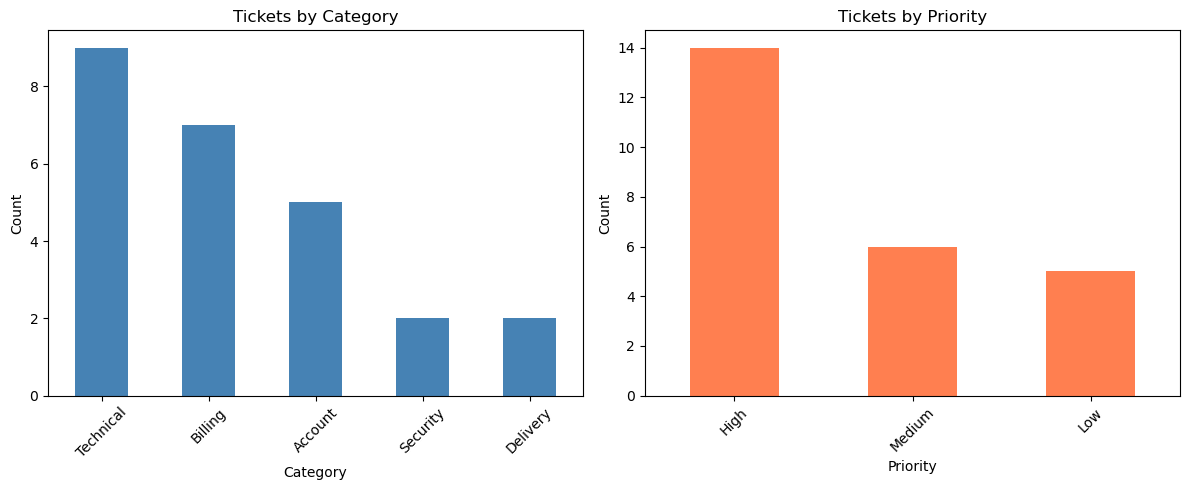


=== SYSTEM SUMMARY ===
Total Tickets Processed: 25
Categories Identified: 5 — ['Security', 'Technical', 'Billing', 'Account', 'Delivery']
Priority Levels: ['High', 'Low', 'Medium']
Category Model Accuracy: 40.00% (limited by small dataset)
Priority Model Accuracy: 80.00%

Note: Accuracy improves significantly with larger real-world datasets.


In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df['category'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Tickets by Category')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

df['priority'].value_counts().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Tickets by Priority')
axes[1].set_xlabel('Priority')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\n=== SYSTEM SUMMARY ===")
print(f"Total Tickets Processed: {len(df)}")
print(f"Categories Identified: {df['category'].nunique()} — {list(df['category'].unique())}")
print(f"Priority Levels: {list(df['priority'].unique())}")
print(f"Category Model Accuracy: 40.00% (limited by small dataset)")
print(f"Priority Model Accuracy: 80.00%")
print("\nNote: Accuracy improves significantly with larger real-world datasets.")